<a href="https://colab.research.google.com/github/rotoncsedu/Computer-Vision/blob/main/Visualizing_Heatmap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [66]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
model = keras.applications.xception.Xception(
    include_top=True,
    weights="imagenet",
)

In [67]:
model.layers[-1].activation = None

In [68]:
import numpy as np
from tensorflow import keras
img_path = keras.utils.get_file("elephant.jpg", "https://img-datasets.s3.amazonaws.com/elephant.jpg")

def get_img_array(img_path, size):
    img = keras.utils.load_img(img_path, target_size=size)
    array = keras.utils.img_to_array(img)
    array = np.expand_dims(array, axis=0)

    return array

img_tensor = get_img_array(img_path, size = (299,299))

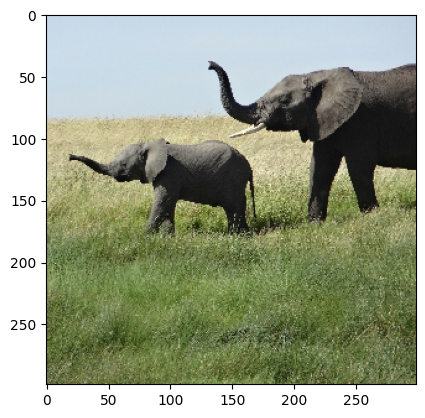

(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

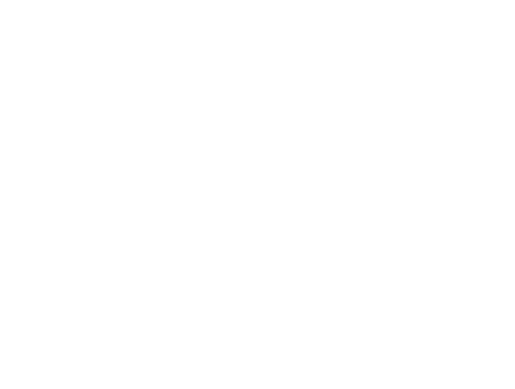

In [69]:
import matplotlib.pyplot as plt
plt.imshow(img_tensor[0].astype("uint8"))
plt.show()
plt.axis("off")

In [70]:
img_tensor = keras.applications.xception.preprocess_input(img_tensor)

In [71]:
pred = model.predict(img_tensor)
print(keras.applications.xception.decode_predictions(pred, top=3)[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
[('n02504458', 'African_elephant', np.float32(10.399574)), ('n01871265', 'tusker', np.float32(7.9743853)), ('n02504013', 'Indian_elephant', np.float32(6.7899246))]


In [72]:
import numpy as np
np.argmax(pred[0])

np.int64(386)

In [73]:
model.summary()

Model: "xception"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_10      │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 149, 149,  │        864 │ input_layer_10[0… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_bn     │ (None, 149, 149,  │        128 │ block1_conv1[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_act    │ (None, 149, 149,  │          0 │ block1_conv1_bn[… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 147, 147,  │     18,432 │ block1_conv1_act… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_bn     │ (None, 147, 147,  │        256 │ block1_conv2[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_act    │ (None, 147, 147,  │          0 │ block1_conv2_bn[… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1     │ (None, 147, 147,  │      8,768 │ block1_conv2_act… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1_bn  │ (None, 147, 147,  │        512 │ block2_sepconv1[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_act │ (None, 147, 147,  │          0 │ block2_sepconv1_… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2     │ (None, 147, 147,  │     17,536 │ block2_sepconv2_… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_bn  │ (None, 147, 147,  │        512 │ block2_sepconv2[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 74, 74,    │      8,192 │ block1_conv2_act… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 74, 74,    │          0 │ block2_sepconv2_… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 74, 74,    │        512 │ conv2d_20[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_60 (Add)        │ (None, 74, 74,    │          0 │ block2_pool[0][0… │
│                     │ 128)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_sepconv1_act │ (None, 74, 74,    │          0 │ add_60[0][0]    

 Total params: 22,910,480 (87.40 MB)

 Trainable params: 22,855,952 (87.19 MB)

 Non-trainable params: 54,528 (213.00 KB)

In [74]:
for layer in model.layers:
    if isinstance(layer, (keras.layers.Conv2D, keras.layers.SeparableConv2D)):
        print(layer.name)

block1_conv1
block1_conv2
block2_sepconv1
block2_sepconv2
conv2d_20
block3_sepconv1
block3_sepconv2
conv2d_21
block4_sepconv1
block4_sepconv2
conv2d_22
block5_sepconv1
block5_sepconv2
block5_sepconv3
block6_sepconv1
block6_sepconv2
block6_sepconv3
block7_sepconv1
block7_sepconv2
block7_sepconv3
block8_sepconv1
block8_sepconv2
block8_sepconv3
block9_sepconv1
block9_sepconv2
block9_sepconv3
block10_sepconv1
block10_sepconv2
block10_sepconv3
block11_sepconv1
block11_sepconv2
block11_sepconv3
block12_sepconv1
block12_sepconv2
block12_sepconv3
block13_sepconv1
block13_sepconv2
conv2d_23
block14_sepconv1
block14_sepconv2


In [75]:
last_conv_layer_name = "block14_sepconv2_act"

last_conv_layer = model.get_layer(
    last_conv_layer_name
)

last_conv_layer_model = keras.Model(
    model.inputs,
    last_conv_layer.output
)



In [76]:
classifier_input = keras.Input(
    shape=last_conv_layer.output.shape[1:]
)

x = classifier_input

for name in ["avg_pool","predictions"]:
    x = model.get_layer(name)(x)

classifier_model = keras.Model(
    classifier_input,
    x
)

classifier_model.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 10, 10, 2048)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avg_pool                        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     2,049,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,049,000 (7.82 MB)

 Trainable params: 2,049,000 (7.82 MB)

 Non-trainable params: 0 (0.00 B)

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_683']
Received: inputs=Tensor(shape=(1, 299, 299, 3))
  warnings.warn(msg)


min: 0.0
max: 1.0
contains nan: False


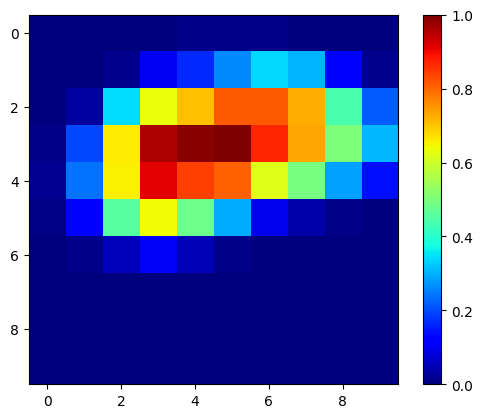

In [77]:
import tensorflow as tf
with tf.GradientTape() as tape:
    last_conv_layer_output = last_conv_layer_model(img_tensor)
    tape.watch(last_conv_layer_output)
    preds = classifier_model(last_conv_layer_output)
    top_pred_index = tf.argmax(preds[0])
    top_class_channel = preds[:, top_pred_index]

grads = tape.gradient(top_class_channel, last_conv_layer_output)
pooled_grads = tf.reduce_mean(grads, axis=(0,1,2)).numpy()
last_conv_layer_output = last_conv_layer_output.numpy()[0]
for i in range(pooled_grads.shape[-1]):
    last_conv_layer_output[:, :, i] *= pooled_grads[i]
heatmap = np.mean(last_conv_layer_output, axis=-1)
heatmap = np.maximum(heatmap,0)

max_val = np.max(heatmap)

if max_val > 0:
    heatmap /= max_val

print("min:", heatmap.min())
print("max:", heatmap.max())
print("contains nan:", np.isnan(heatmap).any())
plt.imshow(heatmap,cmap="jet")
plt.colorbar()
plt.show()

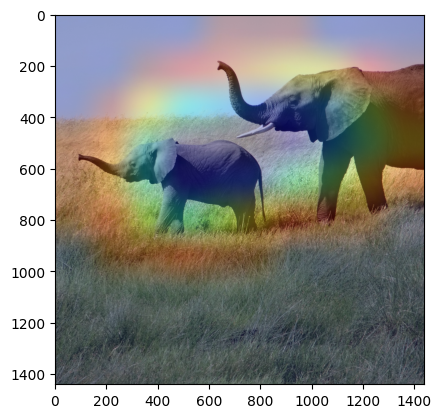

In [81]:
import matplotlib.cm as cm
import matplotlib.pyplot as plt # Import pyplot for colormaps.get_cmap
img = keras.utils.load_img(img_path)
img_arr = keras.utils.img_to_array(img)

heatmap = np.uint8(255 * heatmap)

# Use matplotlib.colormaps.get_cmap for modern usage
jet = plt.colormaps.get_cmap("jet")

jet_colors = jet(np.arange(256))[:, :3]
jet_heatmap = jet_colors[heatmap]

jet_heatmap = keras.utils.array_to_img(jet_heatmap)
# Corrected: Use img.size (width, height) for resize, and ensure correct order
jet_heatmap = jet_heatmap.resize((img.size[0], img.size[1]))
jet_heatmap = keras.utils.img_to_array(jet_heatmap)

# Corrected: Add jet_heatmap (numpy array) to img_arr (numpy array)
superimposed_img = jet_heatmap * 0.4 + img_arr
superimposed_img = keras.utils.array_to_img(superimposed_img)

plt.imshow(superimposed_img)

superimposed_img.save("elephant_cam.jpg")